# 07_visualize.ipynb　概要
- 個人住民税予測モデル - Step7: 結果グラフ化
- 04〜06 の出力を読み込み、グラフを生成して05_results/ フォルダに保存する。

## グラフ一覧
- Fig1. 年度別合算精度（実測 vs 予測）      ← 04 の 04out_yearly_result.csv
- Fig2. 個人税額の誤差分布（ヒストグラム）  ← 04 の 04out_val_result.csv
- Fig3. 予測税額の年齢区分別内訳（棒グラフ）← 05 の 05out_prediction_YYYY.csv
- Fig4. 最終予測サマリー（補正前後の比較）  ← 05/06 の summary CSV
- Fig5. 評価指標ダッシュボード（テーブル + 年度別誤差率）← 04 の val/yearly CSV
- Fig6. 税収時系列グラフ（実績の推移＋予測年の見込み額）← 04 の 04out_yearly_result.csv
- Fig7. ウォークフォワード検証レポート ← 04 の 04out_walkforward_result.csv

## input
- data/04out_yearly_result.csv               ← 04 の出力
- data/04out_val_result.csv                  ← 04 の出力
- data/04out_walkforward_result.csv       ← 04 の出力（walkforward / retrain_all モード時のみ）
- models/model_config.json             ← 04 の出力
- data/05out_prediction_YYYY.csv             ← 05 の出力
- data/05out_prediction_summary_YYYY.csv     ← 05 の出力
- data/06out_prediction_adjusted_summary_YYYY.csv ← 06 の出力（あれば使用）

## output
- 05_results/fig1_yearly_accuracy.png 〜 05_results/fig7_walkforward_report.png

## 実行モードの設定
NOTEBOOK_ARGS は下部の「notebook実行モードの指定」セクションで指定する（--year などの切替）。
notebookでは各グラフを常にその場で表示するため、CLIの `--no-show` に相当する設定はない（各Figの呼び出しで `show=True` を固定指定）。

## このノートブックの構成（2026-09-12 変更）
**人に見せる資料としてそのまま使えるよう、Figごとに「関数定義 → 実行結果」が連続する構成にしている。**
上から順に実行・スクロールすると、各グラフについて「どんなコードで」「どんな図が出るか」を
1つずつ追って確認できる。CLI版（`02_src_py/07_visualize.py`）はmain()に集約した一括実行方式のため、
構成のみが異なりグラフの内容・ロジックは同一。

なお Fig1 で `yearly_df`、Fig2 で `val_df`、Fig3 で `pred_df` を読み込み、
Fig5〜Fig7 はそれらを再利用するため、**上から順に実行する必要がある**。


---

# ファイルパス設定 / ライブラリインポート

In [1]:
import os
import sys
if os.path.basename(os.getcwd()) == "03_notebooks":
    os.chdir("..")
# config.py / tax_reform.py はこのノートブックと同じ 03_notebooks/ にあるため、
# ルートへchdirした後もそこを参照できるよう sys.path に追加する（2026-09-12変更）
sys.path.insert(0, os.path.join(os.getcwd(), "03_notebooks"))

In [2]:
import argparse
import json
import logging
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from config import PREDICT_YEAR

matplotlib.rcParams["font.family"] = ["MS Gothic", "Hiragino Sans", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
# "findfont: Font family 'Hiragino Sans' not found" は matplotlib.font_manager が
# logging 経由で出す警告であり、warnings.filterwarnings では抑制できないため個別に抑制する
# （MS Gothic側は見つかるため表示自体には影響しない）
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

RESULTS_DIR  = "05_results"
YEARLY_PATH  = "data/04out_yearly_result.csv"
VAL_PATH     = "data/04out_val_result.csv"
WF_PATH      = "data/04out_walkforward_result.csv"
MC_PATH      = "models/model_config.json"

# 2026-09-12変更: 旧「80以上」を 80-84 / 85-89 / 90over の3区分に分割（config.py と対応）
AGE_ORDER = [
    "20-24", "25-29", "30-34", "35-39", "40-44", "45-49",
    "50-54", "55-59", "60-64", "65-69", "70-74", "75-79",
    "80-84", "85-89", "90over",
]

---

# notebook実行モードの指定

In [3]:
NOTEBOOK_ARGS = []  # 実行したいモードに応じて上のセルの例のように書き換える

In [4]:
parser = argparse.ArgumentParser()
parser.add_argument("--year", type=int, default=PREDICT_YEAR)
parser.add_argument("--no-show", action="store_true", help="画面表示をスキップ（CLI用。notebookでは常に表示するため未使用）")
args = parser.parse_args(NOTEBOOK_ARGS)  # notebook上ではCLI引数の代わりに NOTEBOOK_ARGS を使用

print(f"=== 07: グラフ生成（{args.year}年度） ===")

=== 07: グラフ生成（2026年度） ===


---

# 出力先フォルダの準備
生成した図の保存先（`05_results/`）を作成する。

In [5]:
os.makedirs(RESULTS_DIR, exist_ok=True)

---

# Fig1: 年度別合算精度（実測 vs 予測）
04 の検証結果をもとに、年度別の実測税収と予測税収を並べて精度を確認する。
入力: `data/04out_yearly_result.csv` ← このセルで `yearly_df` として読み込み、Fig5・Fig6・Fig7でも再利用する。

## 関数定義

In [6]:
def fig1_yearly_accuracy(yearly_df: pd.DataFrame, show: bool):
    """年度別合算精度: 実測 vs 予測 折れ線グラフ"""
    fig, ax = plt.subplots(figsize=(9, 5))
    years = yearly_df["year"]
    ax.plot(years, yearly_df["actual_oku"], "o-", label="実測", color="steelblue", linewidth=2)
    ax.plot(years, yearly_df["pred_oku"],   "s--", label="予測", color="coral",    linewidth=2)

    test_rows = yearly_df[yearly_df["is_test"]]
    if not test_rows.empty:
        ax.axvline(test_rows["year"].min(), color="gray", linestyle=":", linewidth=1.2,
                   label=f"テスト年（{test_rows['year'].min()}年）")

    for _, row in yearly_df.iterrows():
        err = f"{row['error_rate_pct']:+.1f}%"
        ax.annotate(err, (row["year"], row["pred_oku"]),
                    textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}億"))
    ax.set_xlabel("年度")
    ax.set_ylabel("課税合計（億円）")
    ax.set_title("年度別合算精度: 実測 vs 予測")
    ax.legend()
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "fig1_yearly_accuracy.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 実行結果

Fig1: 年度別合算精度


  → 05_results\fig1_yearly_accuracy.png


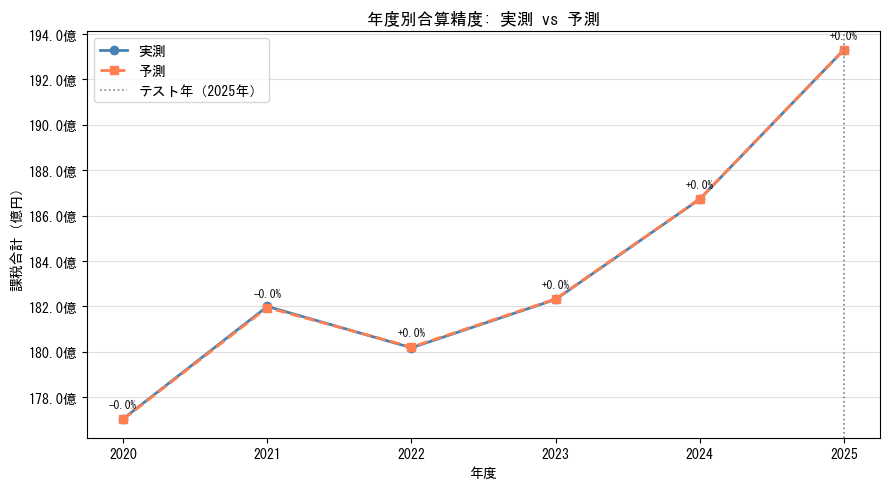

In [7]:
if os.path.exists(YEARLY_PATH):
    print("Fig1: 年度別合算精度")
    yearly_df = pd.read_csv(YEARLY_PATH, encoding="utf-8-sig")
    fig1_yearly_accuracy(yearly_df, show=True)
else:
    yearly_df = None
    print(f"  {YEARLY_PATH} なし → Fig1 スキップ")

---

# Fig2: 個人税額の誤差分布
個人単位の予測誤差（予測 − 実測）の分布をヒストグラムで確認する。
入力: `data/04out_val_result.csv` ← このセルで `val_df` として読み込み、Fig5・Fig7でも再利用する。

## 関数定義

In [8]:
def fig2_error_distribution(val_df: pd.DataFrame, show: bool):
    """個人税額誤差のヒストグラム（テスト年）"""
    errors = val_df["error"].values / 1_000  # 千円単位
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.hist(errors, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("予測誤差（千円）")
    ax.set_ylabel("人数")
    ax.set_title("予測誤差の分布")
    mae_k = np.abs(errors).mean()
    ax.text(0.97, 0.95, f"MAE: {mae_k:.1f}千円", transform=ax.transAxes,
            ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))
    ax.grid(axis="y", alpha=0.4)

    ax2 = axes[1]
    mask   = val_df["tax_amount"] > 0
    mape_v = ((val_df.loc[mask, "pred_tax"] - val_df.loc[mask, "tax_amount"])
              / val_df.loc[mask, "tax_amount"] * 100).values
    ax2.hist(mape_v, bins=60, color="coral", edgecolor="white", alpha=0.85)
    ax2.axvline(0, color="navy", linestyle="--", linewidth=1.2)
    ax2.set_xlabel("予測誤差率（%）")
    ax2.set_ylabel("人数")
    ax2.set_title("予測誤差率の分布（MAPE ベース）")
    mape_m = np.abs(mape_v).mean()
    ax2.text(0.97, 0.95, f"MAPE: {mape_m:.2f}%", transform=ax2.transAxes,
             ha="right", va="top", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))
    ax2.grid(axis="y", alpha=0.4)

    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "fig2_error_distribution.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 実行結果

Fig2: 誤差分布


  → 05_results\fig2_error_distribution.png


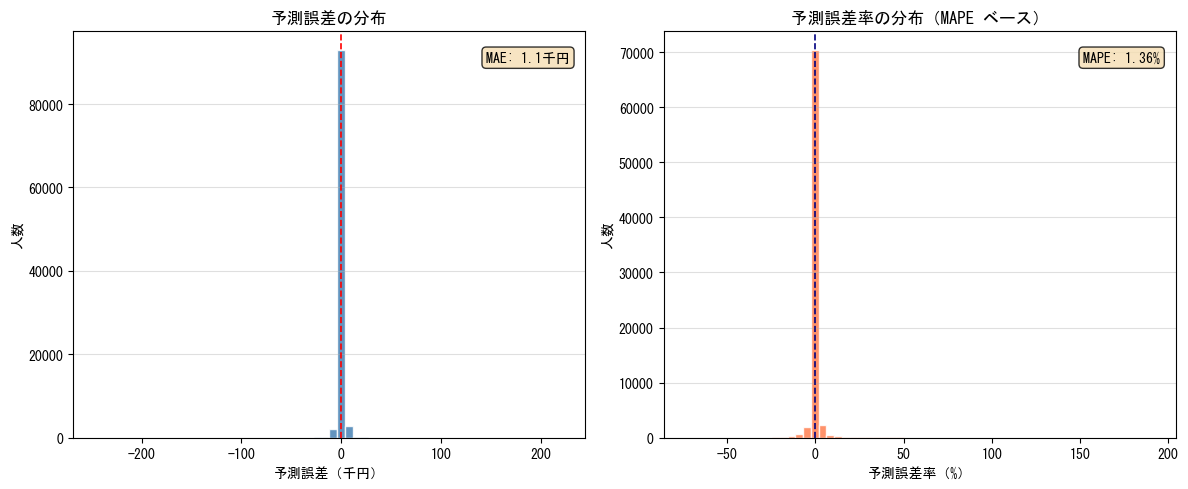

In [9]:
if os.path.exists(VAL_PATH):
    print("Fig2: 誤差分布")
    val_df = pd.read_csv(VAL_PATH, encoding="utf-8-sig")
    fig2_error_distribution(val_df, show=True)
else:
    val_df = None
    print(f"  {VAL_PATH} なし → Fig2 スキップ")

---

# Fig3: 予測税額の年齢区分別内訳
予測税額が年齢区分ごとにどう積み上がっているかを棒グラフで確認する。
入力: `data/05out_prediction_{year}.csv` ← このセルで `pred_df` として読み込む。

## 関数定義

In [10]:
def fig3_age_breakdown(pred_df: pd.DataFrame, year: int, show: bool):
    """年齢区分別 合計税額の棒グラフ"""
    if "age_group" not in pred_df.columns:
        print("  age_group 列なし → fig3 スキップ")
        return

    summary = (
        pred_df.groupby("age_group")["pred_tax_amount"]
        .agg(合計_億円=lambda x: x.sum() / 1e8, 人員="count")
        .reindex(AGE_ORDER).dropna()
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    bars = ax.bar(summary.index, summary["合計_億円"], color="steelblue", alpha=0.85)
    ax.bar_label(bars, fmt="%.2f億", padding=3, fontsize=9)
    ax.set_xlabel("年齢区分")
    ax.set_ylabel("合計税額（億円）")
    ax.set_title(f"{year}年度 年齢区分別 合計税額")
    ax.grid(axis="y", alpha=0.4)
    # 2026-09-12追加: 年齢区分が15個に増えてラベルが重なるため回転させる
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)

    ax2 = axes[1]
    bars2 = ax2.bar(summary.index, summary["人員"] / 1e4, color="coral", alpha=0.85)
    ax2.bar_label(bars2, fmt="%.1f万人", padding=3, fontsize=9)
    ax2.set_xlabel("年齢区分")
    ax2.set_ylabel("納税人員（万人）")
    ax2.set_title(f"{year}年度 年齢区分別 人員")
    ax2.grid(axis="y", alpha=0.4)
    ax2.tick_params(axis="x", labelrotation=45, labelsize=9)

    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, f"fig3_age_breakdown_{year}.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 実行結果

Fig3: 年齢区分別内訳（2026年）


  → 05_results\fig3_age_breakdown_2026.png


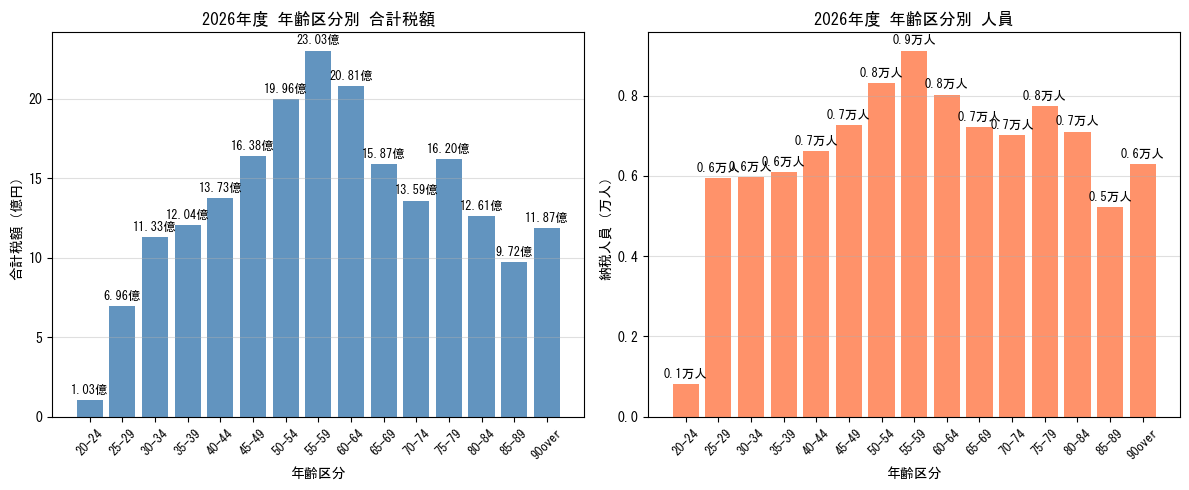

In [11]:
pred_path = f"data/05out_prediction_{args.year}.csv"
if os.path.exists(pred_path):
    print(f"Fig3: 年齢区分別内訳（{args.year}年）")
    pred_df = pd.read_csv(pred_path, encoding="utf-8-sig")
    fig3_age_breakdown(pred_df, args.year, show=True)
else:
    pred_df = None
    print(f"  {pred_path} なし → Fig3 スキップ")

---

# Fig4: 最終予測サマリー（補正前後の比較）
95%信頼区間つきの予測値と、前年実績・補正後最終値を数値テーブルで示す。
入力: `data/05out_prediction_summary_{year}.csv`、`data/06out_prediction_adjusted_summary_{year}.csv`（関数内で読み込む）。

## 関数定義

In [12]:
def fig4_prediction_summary(year: int, show: bool):
    """予測サマリー: 信頼区間つき予測値の図示（上段）+ 数値テーブル（下段）"""
    sum_path = f"data/05out_prediction_summary_{year}.csv"
    adj_path = f"data/06out_prediction_adjusted_summary_{year}.csv"

    if not os.path.exists(sum_path):
        print("  summary CSV なし → fig4 スキップ")
        return

    s        = pd.read_csv(sum_path, encoding="utf-8-sig").iloc[0]
    central  = float(s["予測合計_億円"])
    ci_low   = float(s["CI下限_95%_億円"])
    ci_high  = float(s["CI上限_95%_億円"])
    prev_act = float(s["前年実績_億円"])
    pct_chg  = float(s["前年比率_%"])
    n_people = int(s["予測人員"])

    final_adj = None
    if os.path.exists(adj_path):
        a = pd.read_csv(adj_path, encoding="utf-8-sig").iloc[0]
        if "最終予測合計_億円" in a.index:
            final_adj = float(a["最終予測合計_億円"])

    fig, (ax_main, ax_tbl) = plt.subplots(
        2, 1, figsize=(11, 7),
        gridspec_kw={"height_ratios": [2, 1]},
    )

    # ── 上段: 信頼区間の可視化 ──────────────────────────────────────────────────
    span  = ci_high - ci_low
    x_min = ci_low  - span * 0.65
    x_max = ci_high + span * 0.65
    y0    = 0.0

    # CI 帯
    ax_main.fill_betweenx([y0 - 0.07, y0 + 0.07], ci_low, ci_high,
                          color="steelblue", alpha=0.18)
    ax_main.hlines(y0, ci_low, ci_high, colors="steelblue", linewidth=3.5, zorder=3)

    # 下限・上限の縦棒 + 下向きラベル
    for xv, lbl in [(ci_low,  f"低い見積もり\n{ci_low:.2f} 億円"),
                    (ci_high, f"高い見積もり\n{ci_high:.2f} 億円")]:
        ax_main.plot(xv, y0, "|", color="steelblue",
                     markersize=22, markeredgewidth=2.5, zorder=4)
        ax_main.annotate(lbl,
                         xy=(xv, y0), xytext=(xv, y0 - 0.28),
                         ha="center", va="top", fontsize=10, color="steelblue",
                         arrowprops=dict(arrowstyle="-", color="steelblue", lw=1.0))

    # 前年実績（丸マーカー + 上向きラベル、左寄りにオフセット）
    ax_main.plot(prev_act, y0, "o", color="dimgray", markersize=13, zorder=4)
    ax_main.annotate(f"前年実績\n{prev_act:.2f} 億円",
                     xy=(prev_act, y0),
                     xytext=(prev_act - span * 0.30, y0 + 0.45),
                     ha="center", va="bottom", fontsize=10, color="dimgray",
                     arrowprops=dict(arrowstyle="-", color="dimgray", lw=1.0))

    # 予測中央値（ひし形マーカー + 上向きラベル、右寄りにオフセット）
    ax_main.plot(central, y0, "D", color="steelblue", markersize=14, zorder=5)
    ax_main.annotate(
        f"予測中央値\n{central:.2f} 億円（前年比 {pct_chg:+.2f}%）",
        xy=(central, y0),
        xytext=(central + span * 0.28, y0 + 0.55),
        ha="center", va="bottom", fontsize=12, fontweight="bold", color="steelblue",
        arrowprops=dict(arrowstyle="-", color="steelblue", lw=1.3),
    )

    ax_main.set_xlim(x_min, x_max)
    ax_main.set_ylim(-0.65, 0.95)
    ax_main.set_yticks([])
    ax_main.set_xlabel("課税合計（億円）", fontsize=11)
    ax_main.set_title(f"{year}年度 住民税課税合計 予測結果（95%信頼区間つき）",
                      fontsize=13, fontweight="bold")
    ax_main.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}億"))
    ax_main.grid(axis="x", alpha=0.4)

    # ── 下段: 数値テーブル ──────────────────────────────────────────────────────
    ax_tbl.axis("off")
    table_data = [
        ["前年実績",            f"{prev_act:.2f} 億円", f"{year - 1}年度 確定実績"],
        ["低い見積もり（下限）", f"{ci_low:.2f} 億円",  "95%信頼区間の下限"],
        ["予測中央値",          f"{central:.2f} 億円",  f"前年比 {pct_chg:+.2f}%"],
        ["高い見積もり（上限）", f"{ci_high:.2f} 億円",  "95%信頼区間の上限"],
        ["予測人員",            f"{n_people:,} 人",     f"{year}年度 推計"],
    ]
    if final_adj is not None:
        table_data.insert(4, ["補正後最終値", f"{final_adj:.2f} 億円", "06 マクロ補正後"])

    tbl = ax_tbl.table(
        cellText=table_data,
        colLabels=["項目", "値", "備考"],
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.3, 1.9)
    for j in range(3):
        tbl[(0, j)].set_facecolor("#2c5f8a")
        tbl[(0, j)].set_text_props(color="white", fontweight="bold")
    for j in range(3):  # 予測中央値行をハイライト（ヘッダー=0, 前年=1, 下限=2, 中央=3）
        tbl[(3, j)].set_facecolor("#ddeeff")

    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, f"fig4_summary_{year}.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 実行結果

Fig4: 補正前後比較（2026年）


  → 05_results\fig4_summary_2026.png


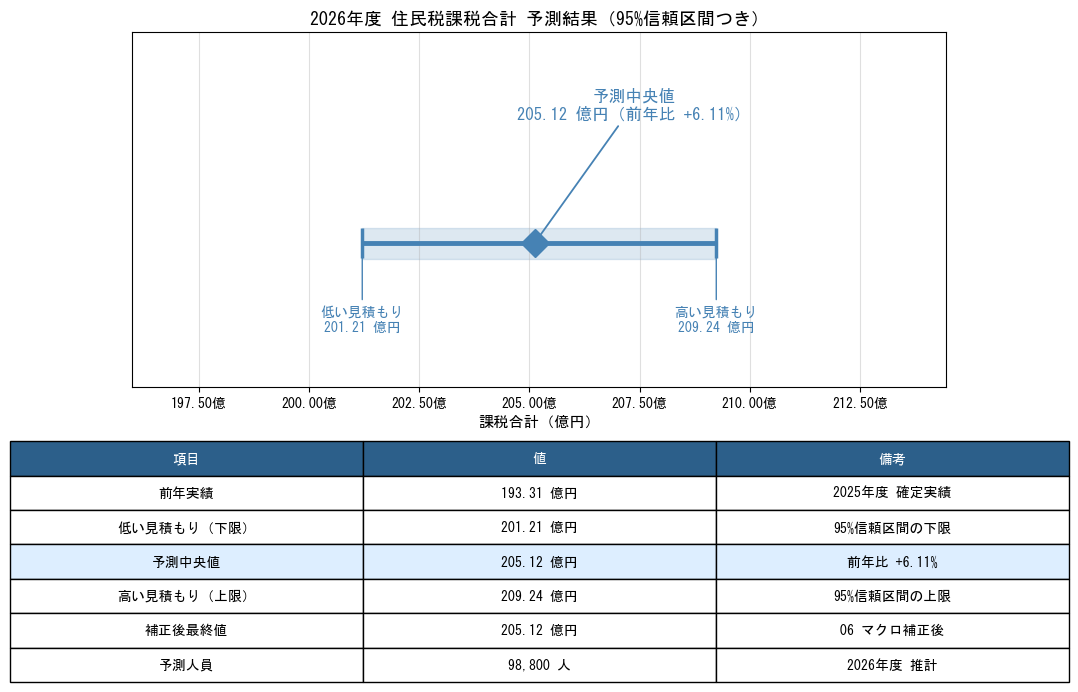

In [13]:
print(f"Fig4: 補正前後比較（{args.year}年）")
fig4_prediction_summary(args.year, show=True)

---

# Fig5: 評価指標ダッシュボード
WMAPE・MAPE・MAE等の評価指標テーブルと、年度別誤差率をまとめて表示する。
入力: Fig1・Fig2で読み込んだ `yearly_df` / `val_df` を再利用する。

## 関数定義

In [14]:
def fig5_metrics_dashboard(val_df: pd.DataFrame, yearly_df: pd.DataFrame, show: bool):
    """評価指標ダッシュボード: テスト年の指標テーブル + 年度別誤差率棒グラフ"""
    # テスト年を特定
    test_mask = yearly_df["is_test"] if "is_test" in yearly_df.columns else pd.Series([False] * len(yearly_df))
    test_year = int(yearly_df.loc[test_mask, "year"].iloc[0]) if test_mask.any() else int(yearly_df["year"].max())

    # 評価指標を計算
    errors = val_df["error"].values
    y_true = val_df["tax_amount"].values
    y_pred = val_df["pred_tax"].values
    mask   = y_true > 0

    mae   = np.abs(errors).mean()
    rmse  = np.sqrt((errors ** 2).mean())
    mape  = np.abs((y_pred[mask] - y_true[mask]) / y_true[mask]).mean() * 100 if mask.any() else float("nan")
    wmape = np.sum(np.abs(errors)) / np.sum(np.abs(y_true)) * 100 if y_true.sum() > 0 else float("nan")
    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2    = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── 左: 評価指標テーブル ──────────────────────────────────────────────────────
    ax = axes[0]
    ax.axis("off")
    table_data = [
        ["MAE",   f"{mae:>10,.0f} 円", "個人税額の平均絶対誤差"],
        ["RMSE",  f"{rmse:>10,.0f} 円", "外れ値に敏感な誤差指標"],
        ["MAPE",  f"{mape:>9.2f} %",   "課税者のみの誤差率"],
        ["WMAPE", f"{wmape:>9.2f} %",  "税収合計の誤差率（主指標）"],
        ["R²",    f"{r2:>11.4f}",      "予測の当てはまり度"],
    ]
    table = ax.table(
        cellText=table_data,
        colLabels=["指標", "値", "説明"],
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.5, 2.2)
    for j in range(3):
        table[(0, j)].set_facecolor("#2c5f8a")
        table[(0, j)].set_text_props(color="white", fontweight="bold")
    for j in range(3):  # WMAPE 行をハイライト（ヘッダー含め4行目 = index 4）
        table[(4, j)].set_facecolor("#fff3cd")
    ax.set_title(f"テスト年（{test_year}年）モデル評価指標",
                 fontsize=12, fontweight="bold", pad=20)

    # ── 右: 年度別誤差率棒グラフ ─────────────────────────────────────────────────
    ax2 = axes[1]
    bar_colors = [
        "coral" if (row["is_test"] if "is_test" in yearly_df.columns else False) else "steelblue"
        for _, row in yearly_df.iterrows()
    ]
    bars = ax2.bar(yearly_df["year"].astype(str), yearly_df["error_rate_pct"],
                   color=bar_colors, alpha=0.85)
    ax2.bar_label(bars,
                  labels=[f"{v:+.2f}%" for v in yearly_df["error_rate_pct"]],
                  padding=3, fontsize=9)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_xlabel("年度")
    ax2.set_ylabel("誤差率（%）")
    ax2.set_title("年度別 合算誤差率（予測 vs 実測）")
    ax2.grid(axis="y", alpha=0.4)
    ax2.legend(handles=[
        Patch(facecolor="steelblue", alpha=0.85, label="訓練年"),
        Patch(facecolor="coral",     alpha=0.85, label="テスト年"),
    ])

    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "fig5_metrics_dashboard.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 実行結果

Fig5: 評価指標ダッシュボード


  → 05_results\fig5_metrics_dashboard.png


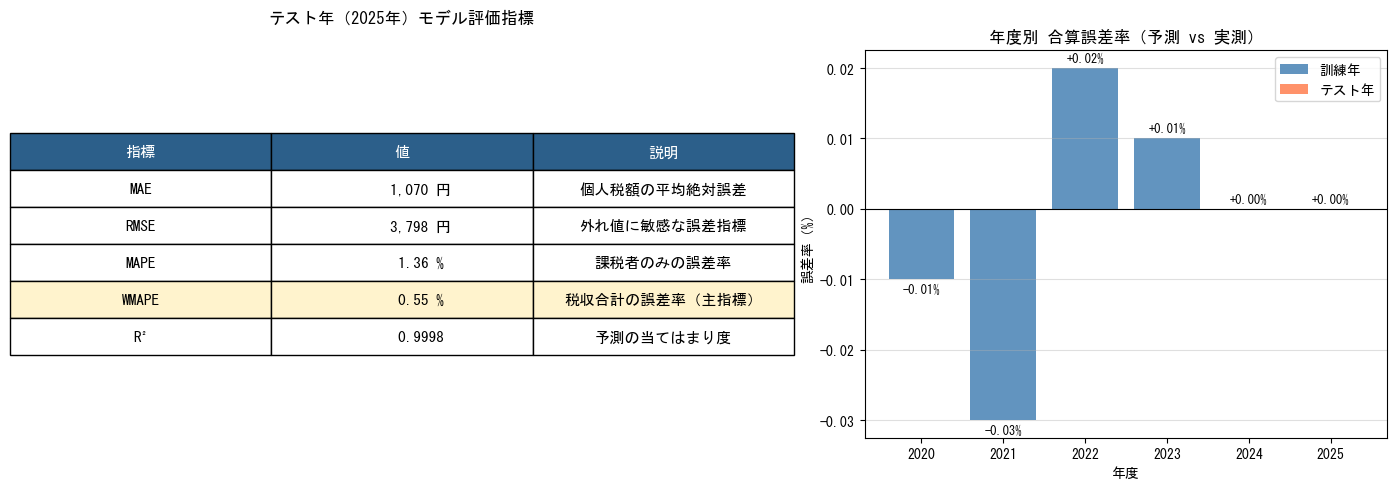

In [15]:
if val_df is not None and yearly_df is not None:
    print("Fig5: 評価指標ダッシュボード")
    fig5_metrics_dashboard(val_df, yearly_df, show=True)
else:
    print("  04out_val_result.csv / 04out_yearly_result.csv なし → Fig5 スキップ")

---

# Fig6: 税収時系列グラフ
過去の実績税収の推移と、予測年の見込み額を時系列で並べる。
入力: Fig1で読み込んだ `yearly_df` を再利用する。

## 関数定義

In [16]:
def fig6_tax_timeseries(yearly_df: pd.DataFrame, year: int, show: bool):
    """税収時系列グラフ: 2020〜前年の実績 + 予測年の予測値（95%信頼区間つき）"""
    sum_path = f"data/05out_prediction_summary_{year}.csv"
    adj_path = f"data/06out_prediction_adjusted_summary_{year}.csv"

    if not os.path.exists(sum_path):
        print("  summary CSV なし → fig6 スキップ")
        return

    s         = pd.read_csv(sum_path, encoding="utf-8-sig").iloc[0]
    pred_val  = float(s["予測合計_億円"])
    ci_low    = float(s["CI下限_95%_億円"])
    ci_high   = float(s["CI上限_95%_億円"])
    pct_chg   = float(s["前年比率_%"])

    # 補正後最終値があれば上書き
    if os.path.exists(adj_path):
        a = pd.read_csv(adj_path, encoding="utf-8-sig").iloc[0]
        if "最終予測合計_億円" in a.index:
            pred_val = float(a["最終予測合計_億円"])

    # 実績系列（04out_yearly_result.csv の actual_oku）
    hist_years = yearly_df["year"].tolist()
    hist_vals  = yearly_df["actual_oku"].tolist()
    all_years  = hist_years + [year]
    all_vals   = hist_vals  + [pred_val]

    fig, ax = plt.subplots(figsize=(11, 6))

    # 実績ライン（全年度の actual を接続）
    ax.plot(hist_years, hist_vals, "o-",
            color="steelblue", linewidth=2.2, markersize=7, label="実績", zorder=4)

    # 実績→予測の接続線（破線）
    ax.plot([hist_years[-1], year], [hist_vals[-1], pred_val],
            "--", color="coral", linewidth=1.8, zorder=3)

    # 予測点
    ax.plot(year, pred_val, "D",
            color="coral", markersize=11, zorder=5, label=f"{year}年度 予測")

    # 95%信頼区間（縦のエラーバー + 塗り）
    ax.fill_between([year - 0.15, year + 0.15], ci_low, ci_high,
                    color="coral", alpha=0.20, zorder=2)
    ax.vlines(year, ci_low, ci_high, colors="coral", linewidth=2.0, zorder=4)
    ax.plot([year - 0.12, year + 0.12], [ci_low,  ci_low],  "-", color="coral", linewidth=2.0)
    ax.plot([year - 0.12, year + 0.12], [ci_high, ci_high], "-", color="coral", linewidth=2.0)

    # 各ポイントに値ラベル
    for yr, val in zip(hist_years, hist_vals):
        ax.annotate(f"{val:.2f}億", (yr, val),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=8, color="steelblue")

    ax.annotate(
        f"予測: {pred_val:.2f}億\n（前年比 {pct_chg:+.2f}%）\n"
        f"CI [{ci_low:.2f}〜{ci_high:.2f}億]",
        xy=(year, pred_val),
        xytext=(year - 0.6, pred_val + (max(all_vals) - min(all_vals)) * 0.18),
        ha="center", fontsize=9, color="coral", fontweight="bold",
        arrowprops=dict(arrowstyle="-", color="coral", lw=1.0),
    )

    # 実績と予測の境界線
    boundary = (hist_years[-1] + year) / 2
    ax.axvline(boundary, color="gray", linestyle=":", linewidth=1.2)
    ax.text(boundary - 0.05, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else min(all_vals) * 0.98,
            "← 実績", ha="right", fontsize=9, color="gray")
    ax.text(boundary + 0.05, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else min(all_vals) * 0.98,
            "予測 →", ha="left",  fontsize=9, color="gray")

    ax.set_xticks(all_years)
    ax.set_xlabel("年度", fontsize=11)
    ax.set_ylabel("住民税課税合計（億円）", fontsize=11)
    ax.set_title(f"住民税課税合計 推移（2020〜{year}年度）", fontsize=13, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}億"))
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()

    path = os.path.join(RESULTS_DIR, f"fig6_tax_timeseries_{year}.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 実行結果

Fig6: 税収時系列グラフ（〜2026年）


  → 05_results\fig6_tax_timeseries_2026.png


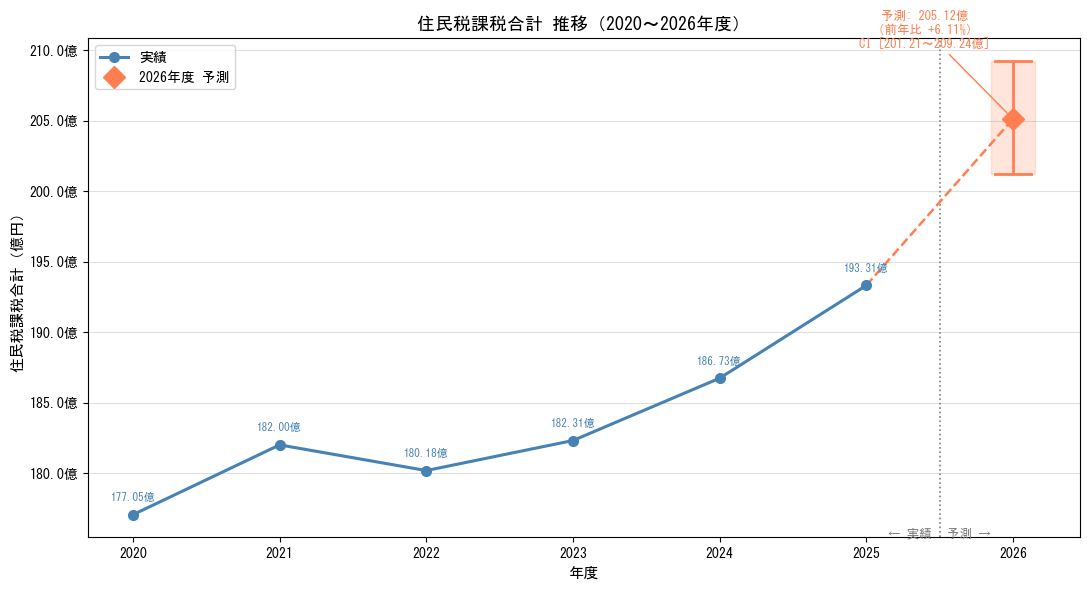

In [17]:
if yearly_df is not None:
    print(f"Fig6: 税収時系列グラフ（〜{args.year}年）")
    fig6_tax_timeseries(yearly_df, args.year, show=True)
else:
    print(f"  {YEARLY_PATH} なし → Fig6 スキップ")

---

# Fig7: ウォークフォワード検証レポート
walk-forward検証の各フォールドの精度推移をまとめたレポート。
入力: `data/04out_walkforward_result.csv`（関数内で読み込み）＋ Fig1・Fig2の `yearly_df` / `val_df`。

## 関数定義

In [18]:
def fig7_walkforward_report(yearly_df: pd.DataFrame, val_df: pd.DataFrame | None, show: bool):
    """ウォークフォワード検証レポート: フォールド別精度テーブル + 誤差率棒グラフ"""
    if not os.path.exists(WF_PATH):
        print(f"  {WF_PATH} なし → Fig7 スキップ")
        print("  ヒント: python 04_model_train.py --walkforward または --retrain-all で生成")
        return

    wf_df = pd.read_csv(WF_PATH, encoding="utf-8-sig")

    # model_config.json から検証モードと最終訓練年度を取得
    mode              = "不明"
    final_train_label = ""
    if os.path.exists(MC_PATH):
        with open(MC_PATH, encoding="utf-8") as f:
            mc = json.load(f)
        mode        = mc.get("validation_mode", "不明")
        train_years = mc.get("train_years", [])
        final_train_label = f"{train_years[0]}〜{train_years[-1]}年" if len(train_years) >= 2 else str(train_years)

    # ── サマリー統計 ────────────────────────────────────────────────────────────
    avg_err  = wf_df["agg_error_pct"].mean()
    std_err  = wf_df["agg_error_pct"].std()
    stable_ok = std_err < 1.5
    bias_ok   = abs(avg_err) < 1.0

    if bias_ok:
        bias_detail = f"平均誤差 {avg_err:+.2f}%（±1%以内）"
    elif avg_err > 0:
        bias_detail = f"過大予測傾向  平均 {avg_err:+.2f}%"
    else:
        bias_detail = f"過小予測傾向  平均 {avg_err:+.2f}%"

    # 過学習判定: 訓練年の平均絶対誤差率 vs テスト年誤差率
    overfit_label, overfit_ok = "判定不可", True
    if yearly_df is not None and "is_test" in yearly_df.columns:
        in_sample_col = "in_sample" if "in_sample" in yearly_df.columns else None
        train_mask    = ~yearly_df["is_test"]
        if in_sample_col:
            train_mask &= ~yearly_df[in_sample_col].fillna(False)
        train_err_avg = yearly_df.loc[train_mask, "error_rate_pct"].abs().mean()
        test_err      = yearly_df.loc[yearly_df["is_test"], "error_rate_pct"].abs()
        if not test_err.empty and train_err_avg > 0:
            ratio = test_err.iloc[0] / train_err_avg
            if ratio > 5:
                overfit_label, overfit_ok = f"過学習の疑い（訓練誤差の {ratio:.1f}x）", False
            elif ratio > 3:
                overfit_label, overfit_ok = f"やや過学習気味（訓練誤差の {ratio:.1f}x）", False
            else:
                overfit_label, overfit_ok = f"問題なし（訓練誤差の {ratio:.1f}x）", True
        elif train_err_avg == 0:
            overfit_label, overfit_ok = "訓練 in-sample 完全適合", True

    # ── レイアウト: 左60% テーブル / 右40% 棒グラフ ─────────────────────────────
    fig, axes = plt.subplots(
        1, 2, figsize=(16, 6.5),
        gridspec_kw={"width_ratios": [1.5, 1]},
    )
    fig.suptitle(
        f"ウォークフォワード検証レポート  [{mode}モード  /  最終訓練年度: {final_train_label}]",
        fontsize=12, fontweight="bold",
    )

    # ── 左: フォールド別精度テーブル ─────────────────────────────────────────────
    ax = axes[0]
    ax.axis("off")

    rows_data    = []
    last_fold_row = 0
    for i, r in wf_df.iterrows():
        parts      = r["train_years"].split("|")
        # 短縮ラベル: "2020〜2021 → 2022" (train=/test= 不要)
        fold_label = f"{parts[0]}〜{parts[-1]}  →  {int(r['test_year'])}"
        rows_data.append([
            fold_label,
            f"{r['actual_oku']:.2f}",
            f"{r['pred_oku']:.2f}",
            f"{r['agg_error_pct']:+.2f}%",
            f"{r['individual_mape']:.1f}%",
        ])
        last_fold_row = i + 1  # ヘッダー=0 なので 1-indexed

    rows_data.append(["平均",    "—", "—", f"{avg_err:+.2f}%", "—"])
    rows_data.append(["標準偏差", "—", "—", f"{std_err:.2f}%",  "—"])
    n_rows = len(rows_data)

    tbl = ax.table(
        cellText=rows_data,
        colLabels=["フォールド", "実測(億円)", "予測(億円)", "誤差率(%)", "個人MAPE(%)"],
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.auto_set_column_width(col=list(range(5)))  # テキスト量に合わせて列幅を自動調整
    tbl.scale(1.0, 2.2)                            # 縦方向のみ拡大（横は auto に任せる）

    for j in range(5):  # ヘッダー
        tbl[(0, j)].set_facecolor("#2c5f8a")
        tbl[(0, j)].set_text_props(color="white", fontweight="bold")
    for j in range(5):  # 最終フォールド（本番テスト年と同条件）を水色ハイライト
        tbl[(last_fold_row, j)].set_facecolor("#ddeeff")
    for j in range(5):  # サマリー行をグレー
        tbl[(n_rows - 1, j)].set_facecolor("#f0f0f0")
        tbl[(n_rows,     j)].set_facecolor("#f0f0f0")

    ax.set_title("フォールド別精度一覧  （水色 = 本番テスト年と同条件）",
                 fontsize=10, pad=8)

    # 判定テキストをテーブルの下に配置
    ok  = lambda f: "✓" if f else "✗"
    clr = lambda f: "#2e7d32" if f else "#c62828"
    judgments = [
        (f"安定性  {ok(stable_ok)}  標準偏差 {std_err:.2f}%（目標 <1.5%）",    clr(stable_ok)),
        (f"バイアス  {ok(bias_ok)}  {bias_detail}",                            clr(bias_ok)),
        (f"過学習  {ok(overfit_ok)}  {overfit_label}",                         clr(overfit_ok)),
    ]
    for idx, (text, color) in enumerate(judgments):
        ax.text(
            0.03, 0.13 - idx * 0.065, text,
            transform=ax.transAxes, fontsize=9,
            color=color, fontweight="bold",
            verticalalignment="top", clip_on=False,
        )

    # ── 右: フォールド別誤差率棒グラフ ───────────────────────────────────────────
    ax2        = axes[1]
    x          = range(len(wf_df))
    parts_list = [r["train_years"].split("|") for _, r in wf_df.iterrows()]
    xlabels    = [
        f"→{int(r['test_year'])}\n({p[0]}〜{p[-1]})"
        for (_, r), p in zip(wf_df.iterrows(), parts_list)
    ]
    colors = ["#C44E52" if abs(v) > 1.0 else "#4C72B0" for v in wf_df["agg_error_pct"]]
    bars   = ax2.bar(x, wf_df["agg_error_pct"], color=colors, alpha=0.85)
    ax2.bar_label(bars, labels=[f"{v:+.2f}%" for v in wf_df["agg_error_pct"]],
                  padding=3, fontsize=9)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.axhspan(-1, 1, alpha=0.12, color="green")
    ax2.set_xticks(x)
    ax2.set_xticklabels(xlabels, fontsize=9)
    ax2.set_ylabel("合算誤差率（%）")
    ax2.set_title("フォールド別 合算誤差率\n目標: ±1%以内")
    ax2.legend(handles=[
        Patch(facecolor="#4C72B0", alpha=0.85, label="誤差 ±1%以内"),
        Patch(facecolor="#C44E52", alpha=0.85, label="誤差 ±1%超"),
        Patch(facecolor="green",   alpha=0.2,  label="±1%帯"),
    ], fontsize=8)
    ax2.grid(axis="y", alpha=0.4)

    plt.tight_layout(rect=[0, 0.0, 1, 0.95])
    path = os.path.join(RESULTS_DIR, "fig7_walkforward_report.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 実行結果

Fig7: ウォークフォワード検証レポート


  → 05_results\fig7_walkforward_report.png


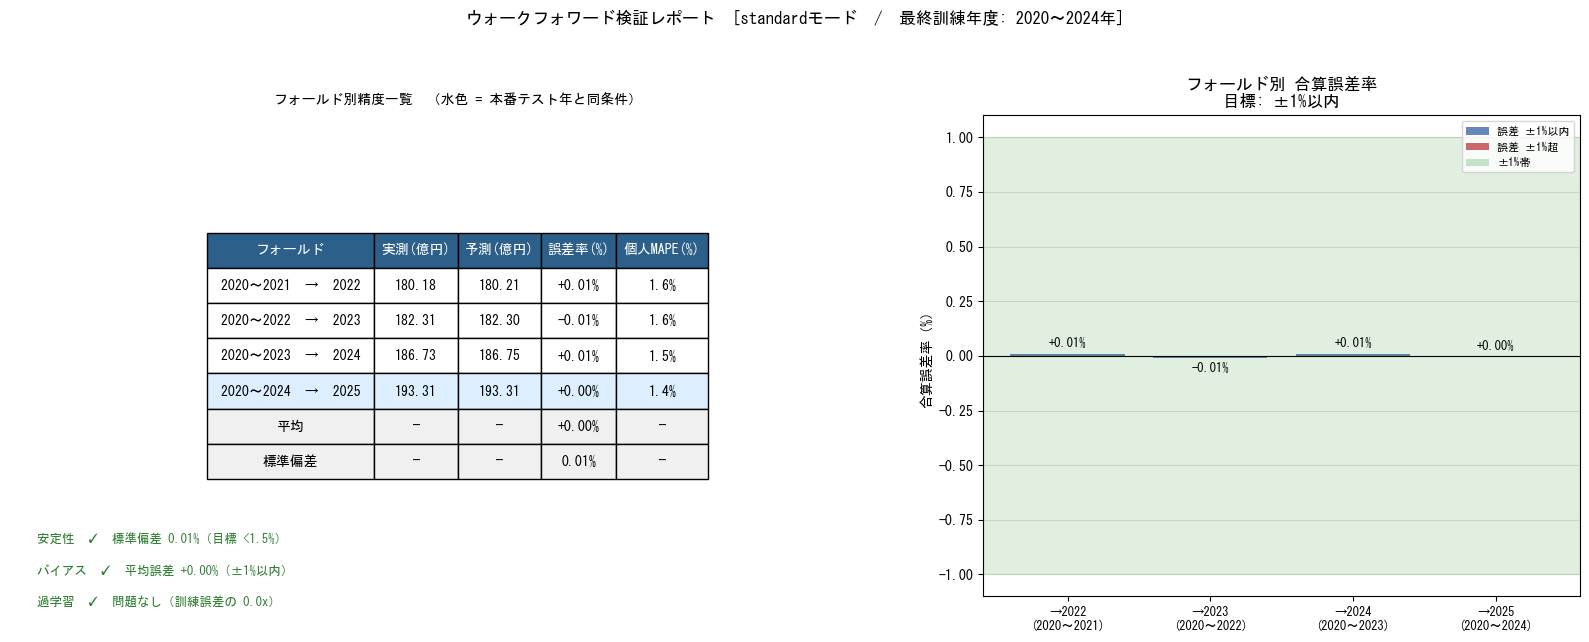

In [19]:
print("Fig7: ウォークフォワード検証レポート")
fig7_walkforward_report(yearly_df, val_df, show=True)

---

# 完了

In [20]:
print(f"全グラフを {RESULTS_DIR}/ に保存しました。")

全グラフを 05_results/ に保存しました。
